# LeetCode #668: Kth Smallest Number in Multiplication Table

https://leetcode.com/problems/kth-smallest-number-in-multiplication-table/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (build table, sort)** | $O(mn \log(mn))$ | $O(mn)$ |
| **Optimal: Binary Search on Value ★** | $O(m \log(mn))$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (build table, sort)
Enumerate all $m \times n$ products, store them, sort, and return the $k$-th. Memory grows to $O(mn)$ which is up to $3 \times 10^4 \times 3 \times 10^4 = 9 \times 10^8$ — infeasible at max constraints.

### Optimal: Binary Search on Value ★
Binary search the answer in $[1, m \cdot n]$. For a candidate value $v$, count how many table entries are $\le v$: row $i$ contributes $\min(\lfloor v/i \rfloor, n)$ values. This counting takes $O(m)$; with $O(\log(mn))$ binary search steps, total is $O(m \log(mn))$ with $O(1)$ space.

**Why this is better than Brute Force:** Avoids materialising the $O(mn)$ table entirely — the binary search works purely on the counting function.

**Constraints:**
* $1 \le m, n \le 3 \times 10^4$
* $1 \le k \le m \times n$


## Solutions

### C#

In [ ]:
public int FindKthNumber(int m, int n, int k) {
    int lo = 1, hi = m * n;
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        // Count table entries <= mid: row i has min(mid/i, n) values
        int count = 0;
        for (int i = 1; i <= m; i++) count += Math.Min(mid / i, n);
        // Shrink search space: if enough entries, mid could be the answer
        if (count >= k) hi = mid;
        else lo = mid + 1;
    }
    return lo;
}


### Python

In [ ]:
def find_kth_number(m: int, n: int, k: int) -> int:
    lo, hi = 1, m * n
    while lo < hi:
        mid = lo + (hi - lo) // 2
        # Count table entries <= mid: row i has min(mid//i, n) values
        count = sum(min(mid // i, n) for i in range(1, m + 1))
        # Shrink search space: if enough entries, mid could be the answer
        if count >= k:
            hi = mid
        else:
            lo = mid + 1
    return lo


### Go

In [ ]:
func findKthNumber(m int, n int, k int) int {
    lo, hi := 1, m*n
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Count table entries <= mid: row i has min(mid/i, n) values
        count := 0
        for i := 1; i <= m; i++ {
            if mid/i < n { count += mid / i } else { count += n }
        }
        // Shrink search space: if enough entries, mid could be the answer
        if count >= k {
            hi = mid
        } else {
            lo = mid + 1
        }
    }
    return lo
}


### Rust

In [ ]:
pub fn find_kth_number(m: i32, n: i32, k: i32) -> i32 {
    let (mut lo, mut hi) = (1i32, m * n);
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        // Count table entries <= mid: row i has min(mid/i, n) values
        let count: i32 = (1..=m).map(|i| (mid / i).min(n)).sum();
        // Shrink search space: if enough entries, mid could be the answer
        if count >= k {
            hi = mid;
        } else {
            lo = mid + 1;
        }
    }
    lo
}


## Example Scenarios

**1. Common Case**
**Input:** m = 3, n = 3, k = 5
Table: [[1,2,3],[2,4,6],[3,6,9]]. Binary search lo=1, hi=9. mid=5: row1=min(5,3)=3, row2=min(2,3)=2, row3=min(1,3)=1 → count=6 ≥ 5 → hi=5. mid=3: count=3+1+1=5 ≥ 5 → hi=3. mid=2: count=2+1+0=3 < 5 → lo=3. Answer: 3.

**2. Slightly Complex**
**Input:** m = 2, n = 3, k = 6
Table: [[1,2,3],[2,4,6]]. k=6 is the largest element. Binary search converges to 6: at mid=6, count=min(6,3)+min(3,3)=3+3=6 ≥ 6 → hi=6; at mid=3, count=3+1=4 < 6 → lo=4; converges to 6.

**3. Edge Case: Time Factor**
**Input:** m = 30000, n = 30000, k = 1 (smallest possible)
Binary search runs $\log_2(9 \times 10^8) \approx 30$ iterations; each scans $m = 30000$ rows. Total $\approx 9 \times 10^5$ operations. Converges to 1 quickly since count(1) = $m$ ≥ 1 pulls hi down immediately.

**4. Edge Case: Space Factor**
**Input:** m = 30000, n = 30000, k = m × n (largest element)
Only five integers used: lo, hi, mid, count, i — pure $O(1)$ space. The virtual $9 \times 10^8$-cell table is never allocated; only the counting formula $\min(v/i, n)$ is evaluated per row.

**5. Almost-Impossible but Plausible**
**Input:** m = 3, n = 3, k = 4
The sorted table is [1,2,2,3,3,4,6,6,9]. k=4 → answer is 3. At mid=3: count(3) = min(3,3)+min(1,3)+min(1,3) = 3+1+1 = 5 ≥ 4 → hi=3. At mid=2: count = 2+1+0 = 3 < 4 → lo=3. Both 2 and 3 appear, but the $k$-th distinct-position value is 3, not 2 — the binary search correctly finds the $k$-th smallest even when duplicates are present.


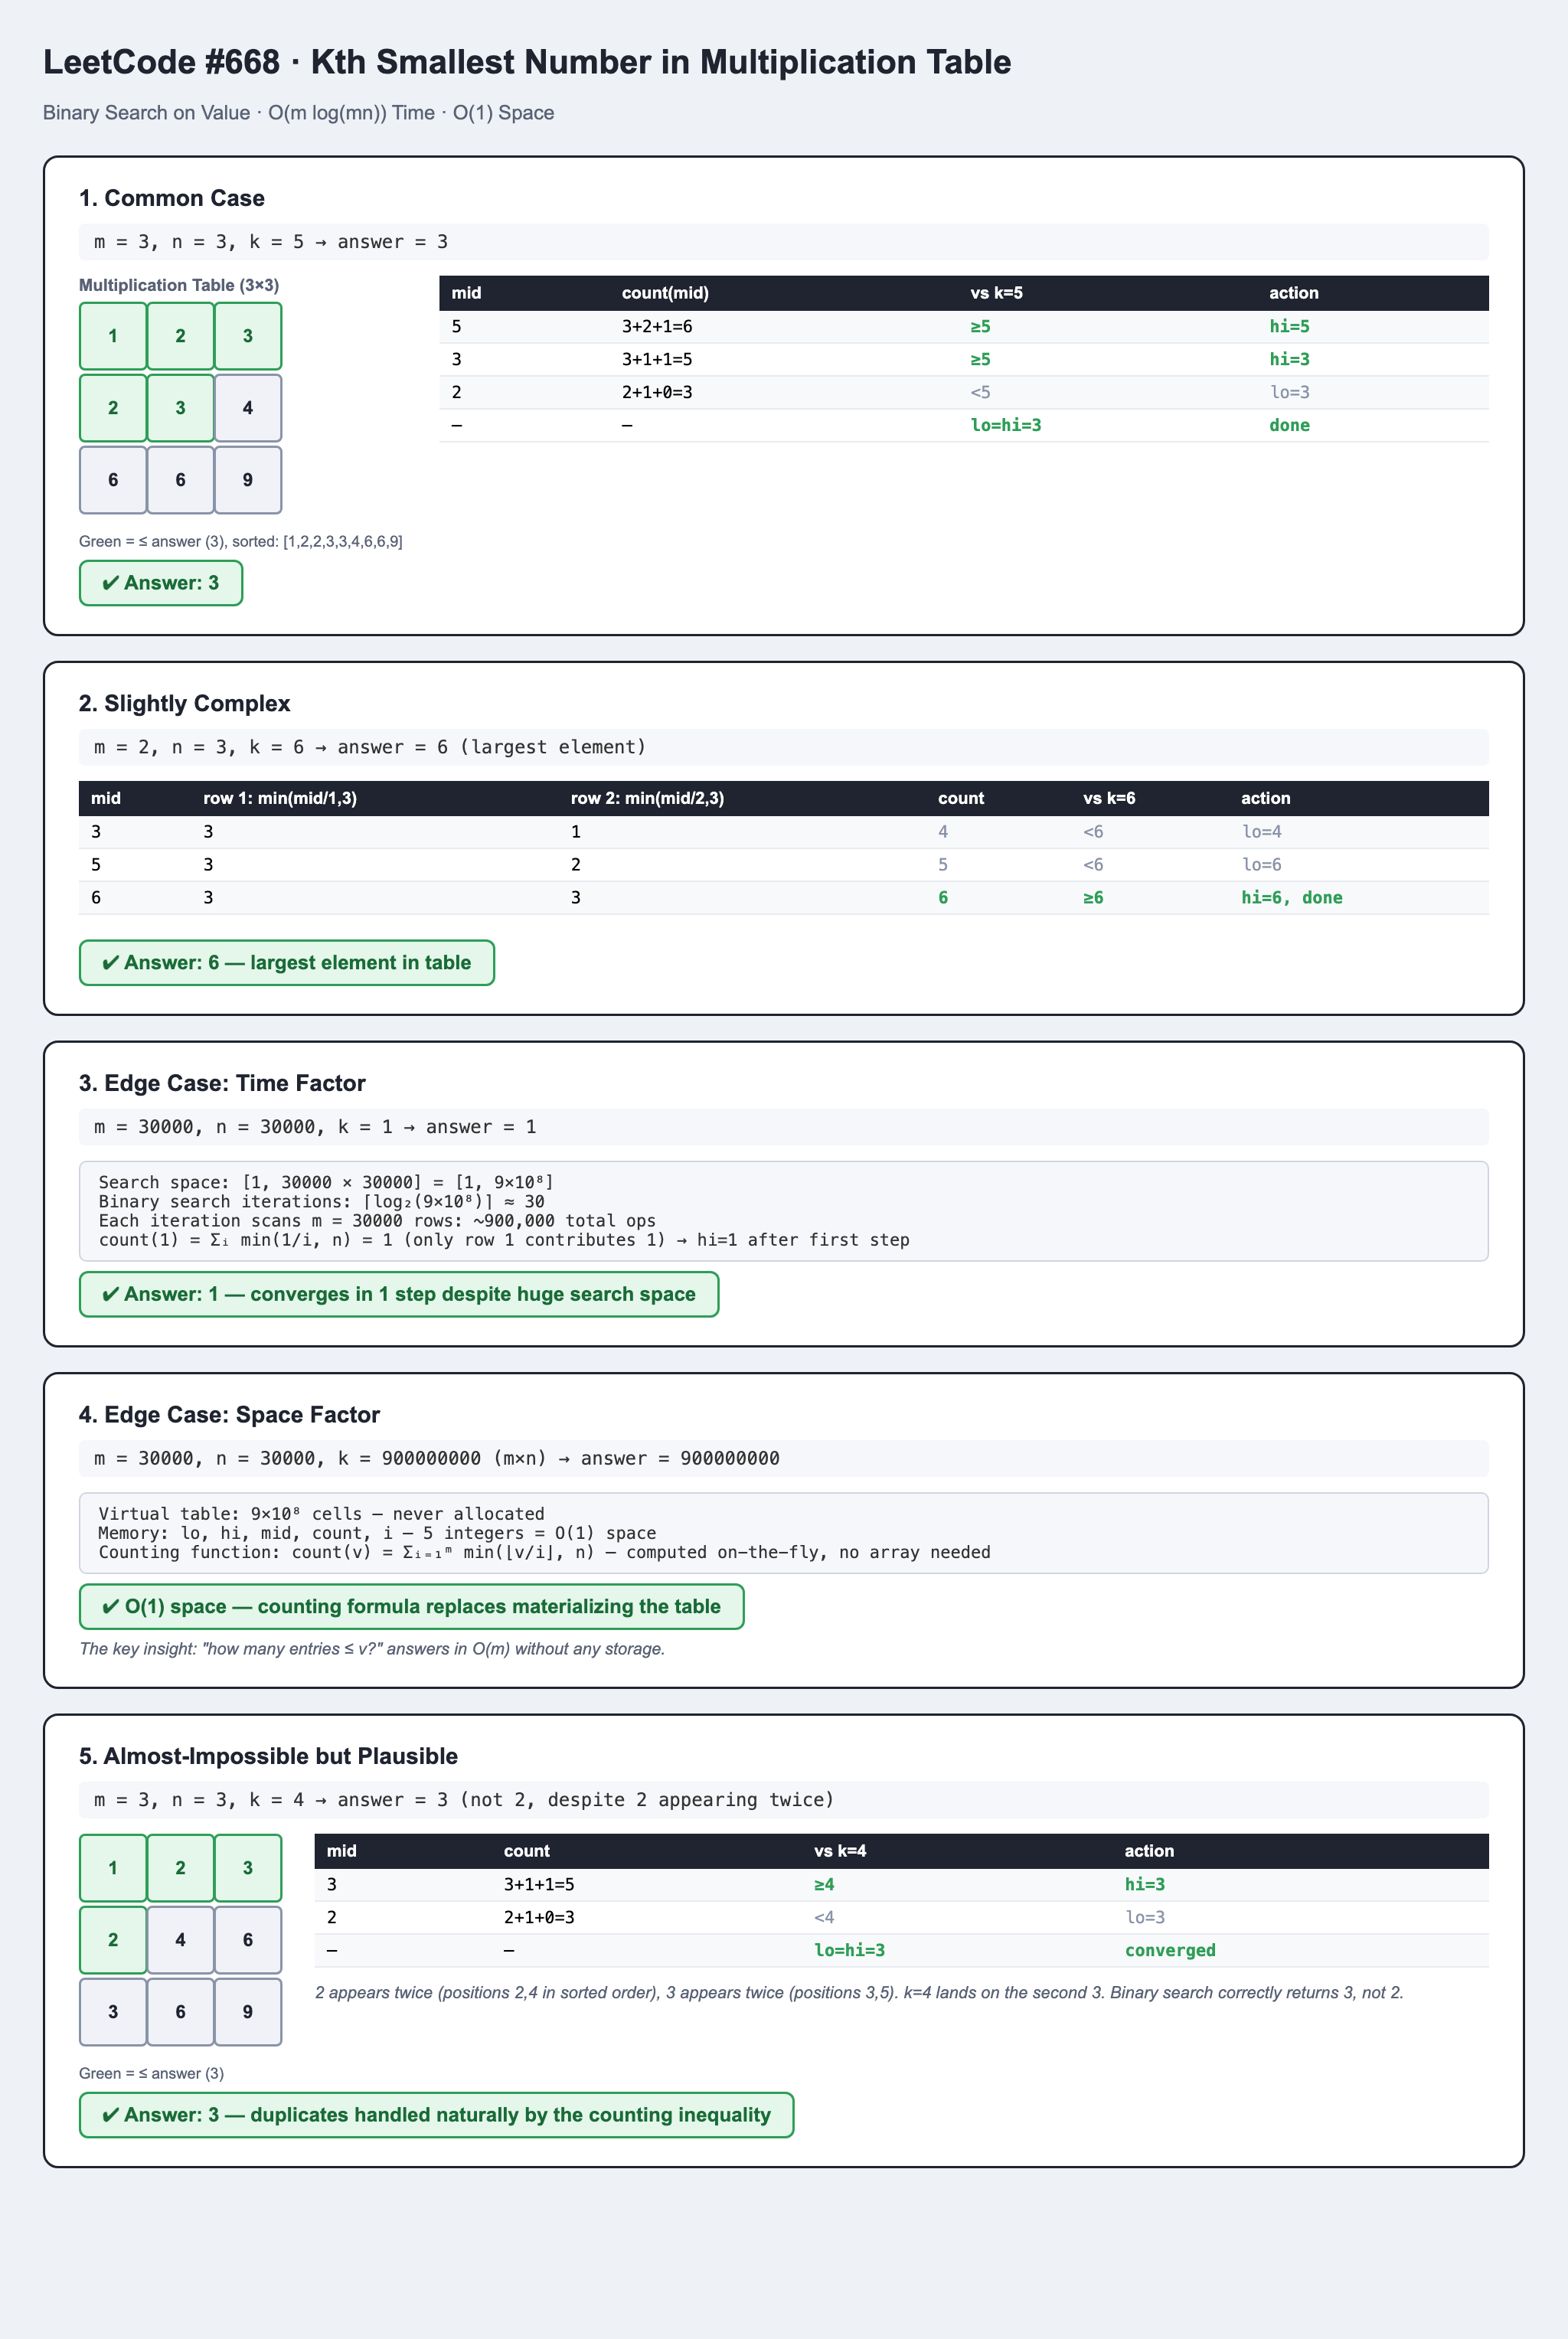